## Customer churn prediction : to analyze historical behavior and identify at-risk users before they leave.

In [137]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/credit-card-customer-churn-prediction


In [138]:
import pandas as pd

In [139]:
df = pd.read_csv(path + "/Churn_Modelling.csv")

In [140]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [141]:
df.info() ## there are no missing values also dtype is also fine.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [142]:
## finding duplicated rows
df.duplicated().sum()

np.int64(0)

In [143]:
df.shape

(10000, 14)

In [144]:
df["Exited"].value_counts()     ## We can see that the data is imbalanced , we are ignoring here.

,count
Exited,
0,7963
1,2037


In [145]:
df["Geography"].value_counts()      ## imbalanced

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [146]:
df["Gender"].value_counts()       ## fairly balanced

,count
Gender,
Male,5457
Female,4543


Row num, customer id, surname : dropped

In [147]:
df.drop(columns = ["RowNumber","CustomerId","Surname"],inplace = True)

In [148]:
## One hot encoding
df = pd.get_dummies(df, columns = ["Geography","Gender"], drop_first= True, dtype=int)

Scaling the values

In [149]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [150]:
from sklearn.model_selection import train_test_split

In [151]:
x = df.drop(columns = ["Exited"])
y = df["Exited"]

In [152]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [153]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()

In [154]:
x_train_scaled = s.fit_transform(x_train)
x_test_scaled = s.transform(x_test)

In [155]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [156]:
model = Sequential()

In [157]:
x_train.shape

(8000, 11)

In [158]:
model.add(Dense(3, activation = "sigmoid", input_dim = x_train.shape[1]))
model.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [159]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [160]:
model.get_weights()

[array([[-0.57771385, -0.5445806 ,  0.5047158 ],
        [ 0.02678066, -0.09705949, -0.5775982 ],
        [-0.39605597, -0.34440637,  0.3846587 ],
        [-0.40659398,  0.33260816, -0.42254925],
        [-0.5011902 , -0.47162038,  0.6363194 ],
        [-0.5840907 ,  0.587173  , -0.12396061],
        [ 0.546659  , -0.09594429, -0.532704  ],
        [-0.539763  ,  0.2077499 ,  0.0818826 ],
        [ 0.20746583,  0.20434201, -0.12863666],
        [-0.02850646, -0.43870026,  0.08171374],
        [-0.59789693, -0.32360882,  0.09833091]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.951074  ],
        [0.81487167],
        [0.40498126]], dtype=float32),
 array([0.], dtype=float32)]

In [161]:
model.compile(loss = "binary_crossentropy", optimizer = "Adam", metrics = ["accuracy"])

In [162]:
model.fit(x_train_scaled, y_train, epochs = 10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2068 - loss: 0.9819
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3779 - loss: 0.7481
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7495 - loss: 0.6249
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7936 - loss: 0.5589
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7933 - loss: 0.5211
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7933 - loss: 0.4973
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7933 - loss: 0.4812
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7933 - loss: 0.4695
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7933 - loss: 0.4600
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7933 - loss: 0.4520


Loss is decreasing

In [163]:
## finding out the values model is an object that has an attribute layers
model.layers[0].get_weights() ## for 1st layer

[array([[-0.27824992, -0.2910362 ,  0.18478988],
        [ 1.0534335 ,  0.7682062 , -1.9720936 ],
        [-0.1643891 , -0.16236104,  0.08734373],
        [-0.09016937,  0.35829362, -0.28802735],
        [-0.5769546 , -0.24912508,  0.22855201],
        [-0.37707785,  0.30717266, -0.02805763],
        [-0.34071052, -0.7463929 ,  0.48340714],
        [-0.15113933,  0.25314978, -0.09011876],
        [ 0.7263919 ,  0.6521701 , -0.60652477],
        [-0.05517829, -0.23191816,  0.01438756],
        [-0.6846093 , -0.50708354,  0.5036922 ]], dtype=float32),
 array([-0.67701477, -0.6059644 ,  0.57215255], dtype=float32)]

In [164]:
model.layers[1].get_weights()

[array([[ 0.39846373],
        [ 0.30569425],
        [-1.003787  ]], dtype=float32),
 array([-1.026111], dtype=float32)]

In [165]:
y_log = model.predict(x_test_scaled)   ## the prediction is not 0 or 1 as we are using sigmoid and it gives probab

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [166]:
## we have to convert the probab
## for finding threshold we have to plot the AUC and ROC curve, for now we are assuming 0.5

In [167]:
y_pred = np.where(y_log>0.5,1,0)

In [168]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [169]:
from sklearn.metrics import accuracy_score

In [170]:
accuracy_score(y_test,y_pred)

0.8085

By doing few changes we can improve the accuracy
1. inc number of epochs
2. making the data balanced
3. using relu activation fn
4. increasing number of nodes
5. using auc and roc for precise threshold
6. increase number of layers, do experimentation to find optimal values


In [171]:
model1 = Sequential()

In [172]:
model1.add(Dense(11, activation = "relu", input_dim = x_train.shape[1]))
model1.add(Dense(11, activation = "relu"))
model1.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [173]:
model1.compile(loss = "binary_crossentropy", optimizer = "Adam", metrics = ["accuracy"])

In [174]:
history = model1.fit(x_train_scaled, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7153 - loss: 0.5662 - val_accuracy: 0.8081 - val_loss: 0.4661
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7927 - loss: 0.4617 - val_accuracy: 0.8175 - val_loss: 0.4299
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - loss: 0.4318 - val_accuracy: 0.8306 - val_loss: 0.4035
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8258 - loss: 0.4076 - val_accuracy: 0.8425 - val_loss: 0.3789
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8394 - loss: 0.3859 - val_accuracy: 0.8469 - val_loss: 0.3617
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8492 - loss: 0.3708 - val_accuracy: 0.8519 - val_loss: 0.3486
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8525 - loss: 0.3603 - val_accuracy: 0.8556 - val_loss: 0.3415
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8561 - loss: 0.3541 - val_accu

In [175]:
y_log1 = model1.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [176]:
import numpy as np

In [177]:
y_pred2 = np.where(y_log1 >0.5,1,0)

In [178]:
accuracy_score(y_test,y_pred2)

0.86

GOAL
1. Loss should reduce and accuracy should be increasing
2. Ensure that both training and val accuracy are increasing with epochs
3. If only training accuracy is increasing and validation accuracy is stagnated then this is case of overfitting

In [179]:
## history gives a dictionary that stores all the info about the model
import matplotlib.pyplot as plt

In [180]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

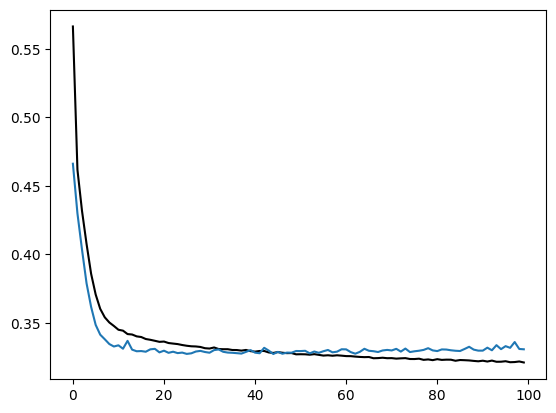

In [181]:
plt.plot(history.history["loss"],color = "black")
plt.plot(history.history["val_loss"])



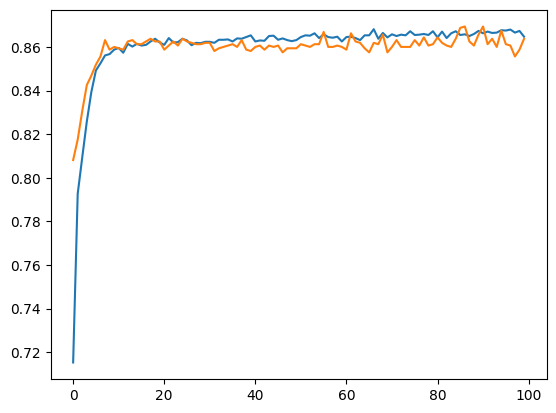

In [182]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
#plt.ylim(0.78,0.86)